#MODELO ANN

Iteration 1, loss = 0.15544084
Validation score: 0.951365
Iteration 2, loss = 0.13236655
Validation score: 0.953517
Iteration 3, loss = 0.13090585
Validation score: 0.952349
Iteration 4, loss = 0.12997243
Validation score: 0.952164
Iteration 5, loss = 0.12941519
Validation score: 0.952410
Iteration 6, loss = 0.12904106
Validation score: 0.952349
Iteration 7, loss = 0.12880473
Validation score: 0.952841
Iteration 8, loss = 0.12844062
Validation score: 0.953087
Iteration 9, loss = 0.12836095
Validation score: 0.954316
Iteration 10, loss = 0.12807868
Validation score: 0.953148
Iteration 11, loss = 0.12805447
Validation score: 0.953886
Iteration 12, loss = 0.12791560
Validation score: 0.953763
Iteration 13, loss = 0.12762399
Validation score: 0.952595
Iteration 14, loss = 0.12744709
Validation score: 0.951734
Iteration 15, loss = 0.12705770
Validation score: 0.953087
Iteration 16, loss = 0.12689712
Validation score: 0.952349
Iteration 17, loss = 0.12680645
Validation score: 0.953763
Iterat

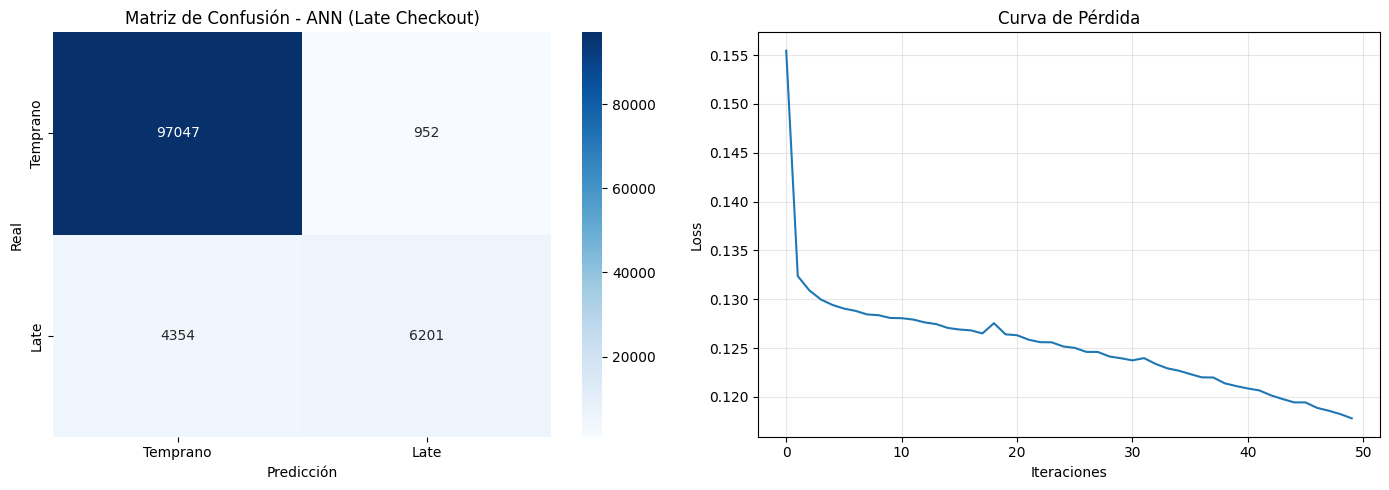


✅ Modelo guardado: ann.pkl


In [ ]:
# =============================================================================
# ENTRENAMIENTO DE ANN PARA PREDECIR LATE CHECKOUT - VERSIÓN FINAL
# =============================================================================

import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df_train = pd.read_csv('/content/drive/MyDrive/PERSONAL PROJECTS/Hotel_Checkout/hotel_train_2024.csv')
df_test = pd.read_csv('/content/drive/MyDrive/PERSONAL PROJECTS/Hotel_Checkout/hotel_test_2025.csv')

cat_features = ['sector', 'tipo_habitacion', 'nacionalidad', 'segmento']
# =============================================================================
# MODIFICADO: Añadir 'is_checkout' a las features numéricas
# =============================================================================
num_features = ['planta', 'noches_estancia', 'num_huespedes', 'dia_semana', 'mes', 'is_checkout']
bool_features = ['tiene_ninos']
target = 'late_checkout'
# =============================================================================

def preparar_features(df, fit=True, encoders=None):
    df_prep = df.copy()
    if fit:
        encoders = {}
        for col in cat_features:
            le = LabelEncoder()
            df_prep[f'{col}_encoded'] = le.fit_transform(df_prep[col].astype(str))
            encoders[col] = le
    else:
        for col in cat_features:
            le = encoders[col]
            df_prep[f'{col}_encoded'] = df_prep[col].astype(str).apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    feature_cols = num_features + bool_features + [f'{col}_encoded' for col in cat_features]
    X = df_prep[feature_cols].values.astype(np.float64)
    y = df_prep[target].values.astype(np.int64)
    return X, y, encoders, feature_cols

X_train, y_train, encoders, feature_cols = preparar_features(df_train, fit=True)
X_test, y_test, _, _ = preparar_features(df_test, fit=False, encoders=encoders)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=128,
    learning_rate='adaptive',
    learning_rate_init=0.0005,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=40,
    random_state=42,
    verbose=True
)

ann_model.fit(X_train_scaled, y_train)

y_pred_train = ann_model.predict(X_train_scaled)
y_pred_test = ann_model.predict(X_test_scaled)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\nAccuracy Train: {acc_train:.4f} ({acc_train:.2%})")
print(f"Accuracy Test:  {acc_test:.4f} ({acc_test:.2%})")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test, target_names=['Checkout temprano', 'Late checkout']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Temprano', 'Late'], yticklabels=['Temprano', 'Late'], ax=axes[0])
axes[0].set_title('Matriz de Confusión - ANN (Late Checkout)')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')
axes[1].plot(ann_model.loss_curve_)
axes[1].set_title('Curva de Pérdida')
axes[1].set_xlabel('Iteraciones')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ann_artifacts = {
    'modelo': ann_model,
    'scaler': scaler,
    'encoders': encoders,
    'feature_cols': feature_cols,
    'cat_features': cat_features,
    'num_features': num_features,
    'bool_features': bool_features,
    'accuracy_test': acc_test
}

with open('ann.pkl', 'wb') as f:
    pickle.dump(ann_artifacts, f)

print("\n✅ Modelo guardado: ann.pkl")

#MODELO XGBoost

Features: 11
Train: 108425 muestras
Test: 108554 muestras
Tiempo medio train: 35.2 min
Tiempo medio test: 35.3 min

MAE Train: 1.87 minutos
MAE Test:  1.90 minutos
RMSE Train: 2.34 minutos
RMSE Test:  2.36 minutos
R² Train: 0.9631
R² Test:  0.9627

Top 10 features:
  is_checkout              : 0.8711
  sector_encoded           : 0.0931
  planta                   : 0.0094
  tipo_habitacion_encoded  : 0.0093
  segmento_encoded         : 0.0090
  noches_estancia          : 0.0068
  tiene_ninos              : 0.0006
  dia_semana               : 0.0006
  num_huespedes            : 0.0001
  nacionalidad_encoded     : 0.0000


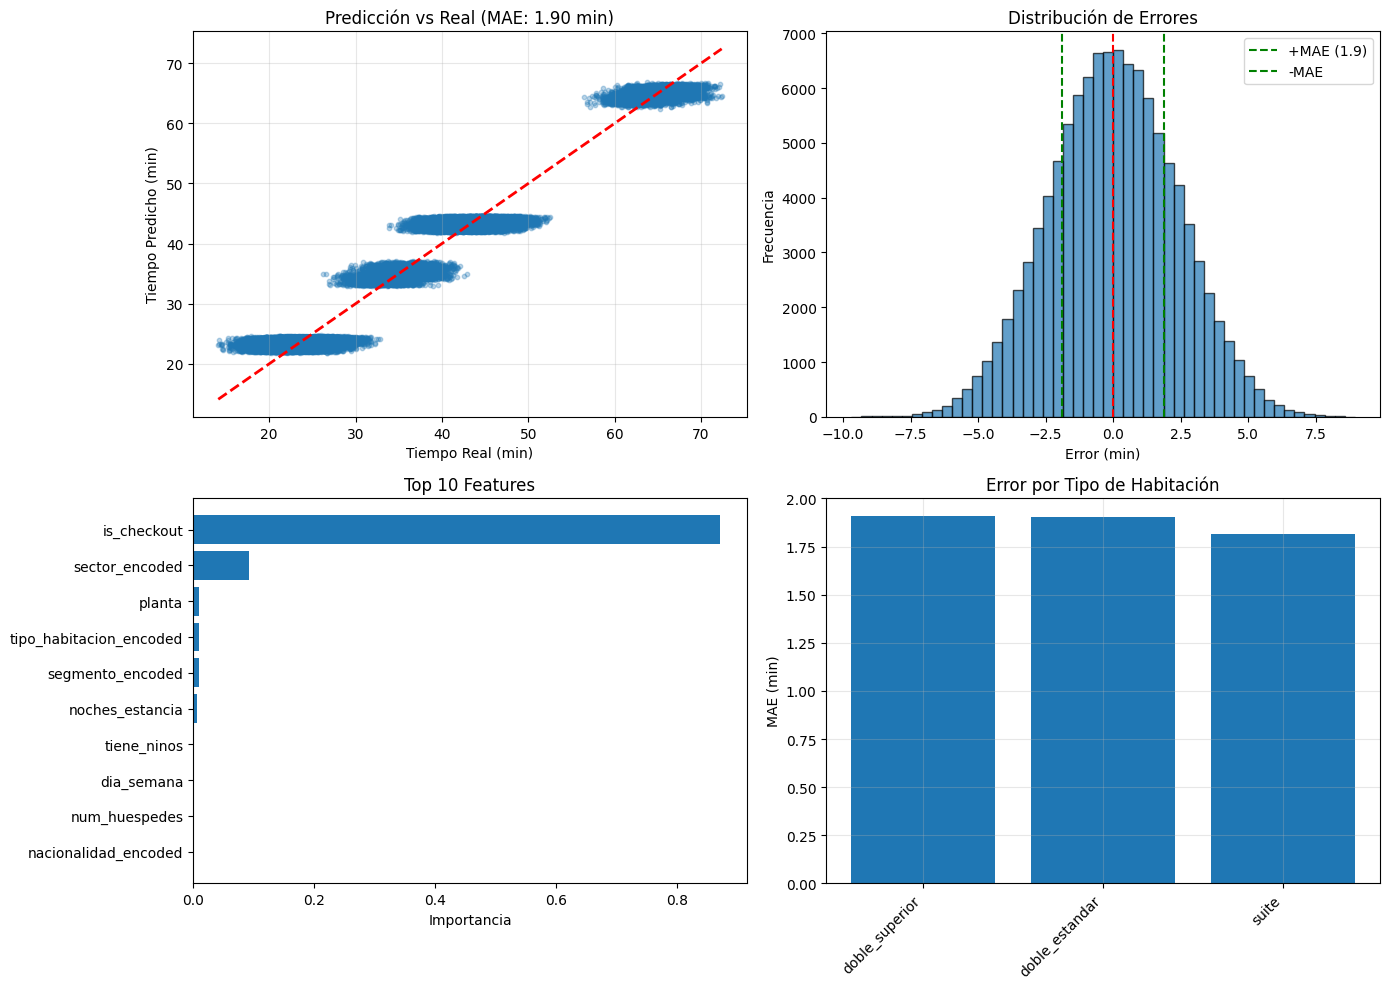


✅ Modelo guardado: xgboost.pkl


In [ ]:
# =============================================================================
# ENTRENAMIENTO DE XGBOOST PARA PREDECIR TIEMPO DE LIMPIEZA
# =============================================================================

import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder, StandardScaler  # <--- AÑADIDO StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df_train = pd.read_csv('/content/drive/MyDrive/PERSONAL PROJECTS/Hotel_Checkout/hotel_train_2024.csv')
df_test = pd.read_csv('/content/drive/MyDrive/PERSONAL PROJECTS/Hotel_Checkout/hotel_test_2025.csv')

cat_features = ['sector', 'tipo_habitacion', 'nacionalidad', 'segmento']
# =============================================================================
# MODIFICADO: Añadir 'is_checkout' a las features numéricas
# =============================================================================
num_features = ['planta', 'noches_estancia', 'num_huespedes', 'dia_semana', 'mes', 'is_checkout']
bool_features = ['tiene_ninos']
target = 'tiempo_estimado'
# =============================================================================

def preparar_features_xgb(df, fit=True, encoders=None):
    df_prep = df.copy()
    if fit:
        encoders = {}
        for col in cat_features:
            le = LabelEncoder()
            df_prep[f'{col}_encoded'] = le.fit_transform(df_prep[col].astype(str))
            encoders[col] = le
    else:
        for col in cat_features:
            le = encoders[col]
            df_prep[f'{col}_encoded'] = df_prep[col].astype(str).apply(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )
    feature_cols = num_features + bool_features + [f'{col}_encoded' for col in cat_features]
    X = df_prep[feature_cols].values
    y = df_prep[target].values
    return X, y, encoders, feature_cols

X_train, y_train, encoders_xgb, feature_cols = preparar_features_xgb(df_train, fit=True)
X_test, y_test, _, _ = preparar_features_xgb(df_test, fit=False, encoders=encoders_xgb)

print(f"Features: {len(feature_cols)}")
print(f"Train: {len(X_train)} muestras")
print(f"Test: {len(X_test)} muestras")
print(f"Tiempo medio train: {y_train.mean():.1f} min")
print(f"Tiempo medio test: {y_test.mean():.1f} min")

# =============================================================================
# NUEVO: ESCALAR LA VARIABLE OBJETIVO
# =============================================================================
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).ravel()
# =============================================================================

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50,
    eval_metric='mae'
)

eval_set = [(X_train, y_train_scaled), (X_test, y_test_scaled)]  # <--- USAR y_train_scaled
xgb_model.fit(X_train, y_train_scaled, eval_set=eval_set, verbose=False)

y_pred_train_scaled = xgb_model.predict(X_train)
y_pred_test_scaled = xgb_model.predict(X_test)

# =============================================================================
# NUEVO: APLICAR TRANSFORMACIÓN INVERSA PARA MÉTRICAS EN MINUTOS REALES
# =============================================================================
y_pred_train = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1)).ravel()
y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled.reshape(-1, 1)).ravel()
# =============================================================================

mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"\nMAE Train: {mae_train:.2f} minutos")
print(f"MAE Test:  {mae_test:.2f} minutos")
print(f"RMSE Train: {rmse_train:.2f} minutos")
print(f"RMSE Test:  {rmse_test:.2f} minutos")
print(f"R² Train: {r2_train:.4f}")
print(f"R² Test:  {r2_test:.4f}")

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)
print("\nTop 10 features:")
for i, row in importance.head(10).iterrows():
    print(f"  {row['feature']:25s}: {row['importance']:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].scatter(y_test, y_pred_test, alpha=0.3, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Tiempo Real (min)')
axes[0, 0].set_ylabel('Tiempo Predicho (min)')
axes[0, 0].set_title(f'Predicción vs Real (MAE: {mae_test:.2f} min)')
axes[0, 0].grid(True, alpha=0.3)

errores = y_test - y_pred_test
axes[0, 1].hist(errores, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].axvline(x=mae_test, color='g', linestyle='--', label=f'+MAE ({mae_test:.1f})')
axes[0, 1].axvline(x=-mae_test, color='g', linestyle='--', label=f'-MAE')
axes[0, 1].set_xlabel('Error (min)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Errores')
axes[0, 1].legend()

top_features = importance.head(10)
axes[1, 0].barh(top_features['feature'], top_features['importance'])
axes[1, 0].set_xlabel('Importancia')
axes[1, 0].set_title('Top 10 Features')
axes[1, 0].invert_yaxis()

errores_por_tipo = []
tipos = df_test['tipo_habitacion'].unique()
for tipo in tipos:
    mask = df_test['tipo_habitacion'] == tipo
    idx = df_test[mask].index
    idx_adjusted = [i - df_test.index[0] for i in idx]
    mae_tipo = mean_absolute_error(y_test[mask], y_pred_test[idx_adjusted])
    errores_por_tipo.append(mae_tipo)

axes[1, 1].bar(range(len(tipos)), errores_por_tipo)
axes[1, 1].set_xticks(range(len(tipos)))
axes[1, 1].set_xticklabels(tipos, rotation=45, ha='right')
axes[1, 1].set_ylabel('MAE (min)')
axes[1, 1].set_title('Error por Tipo de Habitación')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

xgboost_artifacts = {
    'modelo': xgb_model,
    'encoders': encoders_xgb,
    'feature_cols': feature_cols,
    'cat_features': cat_features,
    'num_features': num_features,
    'bool_features': bool_features,
    'target': target,
    'scaler_y': scaler_y,  # <--- NUEVO: GUARDAR EL ESCALADOR
    'metricas': {
        'mae_train': mae_train,
        'mae_test': mae_test,
        'rmse_train': rmse_train,
        'rmse_test': rmse_test,
        'r2_train': r2_train,
        'r2_test': r2_test
    }
}

with open('xgboost.pkl', 'wb') as f:
    pickle.dump(xgboost_artifacts, f)

print("\n✅ Modelo guardado: xgboost.pkl")

In [ ]:
# ==============================================================
# Predicción con el modelo XGBoost para un índice específico
# ==============================================================

# Se puede cambiar este índice para probar diferentes ejemplos
sample_index = 1

# Seleccionar la fila de prueba
sample_df = df_test.iloc[[sample_index]].copy()

# Re-usar la función de preparación de features y los encoders del modelo XGBoost
# df_test y encoders_xgb están disponibles desde la ejecución de la celda del modelo XGBoost

# Preparar las características para la muestra, usando los encoders ya entrenados
X_sample, y_sample, _, _ = preparar_features_xgb(sample_df, fit=False, encoders=encoders_xgb)

# Asegurarse de que X_sample tenga la forma correcta para la predicción (2D array)
# En este caso, X_sample ya es un array 2D ya que sample_df tiene una fila.

# Realizar la predicción (el modelo devuelve la predicción escalada)
predicted_tiempo_estimado_scaled = xgb_model.predict(X_sample)

# Obtener el scaler_y del diccionario de artefactos de XGBoost
scaler_y = xgboost_artifacts['scaler_y']

# Aplicar la transformación inversa a la predicción para obtener el valor real en minutos
predicted_tiempo_estimado = scaler_y.inverse_transform(predicted_tiempo_estimado_scaled.reshape(-1, 1)).ravel()

print(f"Datos de la muestra (índice {sample_index}):")
# Imprimir también los datos originales de la muestra para una mejor depuración
display(sample_df)

print("\nCaracterísticas utilizadas para la predicción:")
for col in feature_cols:
    print(f"  {col}: {X_sample[0][feature_cols.index(col)]}")

print(f"\nValor REAL de tiempo_estimado: {y_sample[0]:.2f} minutos")
print(f"Valor PREDECIDO de tiempo_estimado: {predicted_tiempo_estimado[0]:.2f} minutos")
print(f"Diferencia: {(predicted_tiempo_estimado[0] - y_sample[0]):.2f} minutos")

Datos de la muestra (índice 1):


,fecha,habitacion_id,planta,sector,tipo_habitacion,noches_estancia,nacionalidad,num_huespedes,tiene_ninos,segmento,dia_semana,mes,is_checkout,late_checkout,tiempo_estimado,tiempo_real,incidencia_camarera,opinion_cliente,sentimiento_nlp
1,2025-01-01,710,7,bajo,doble_estandar,4,Reino Unido,3,False,Familia,2,1,0,0,23.0,25,NaN,NaN,NaN



Características utilizadas para la predicción:
  planta: 7
  noches_estancia: 4
  num_huespedes: 3
  dia_semana: 2
  mes: 1
  is_checkout: 0
  tiene_ninos: False
  sector_encoded: 1
  tipo_habitacion_encoded: 0
  nacionalidad_encoded: 3
  segmento_encoded: 1

Valor REAL de tiempo_estimado: 23.00 minutos
Valor PREDECIDO de tiempo_estimado: 23.33 minutos
Diferencia: 0.33 minutos


#MODELO K-MEANS

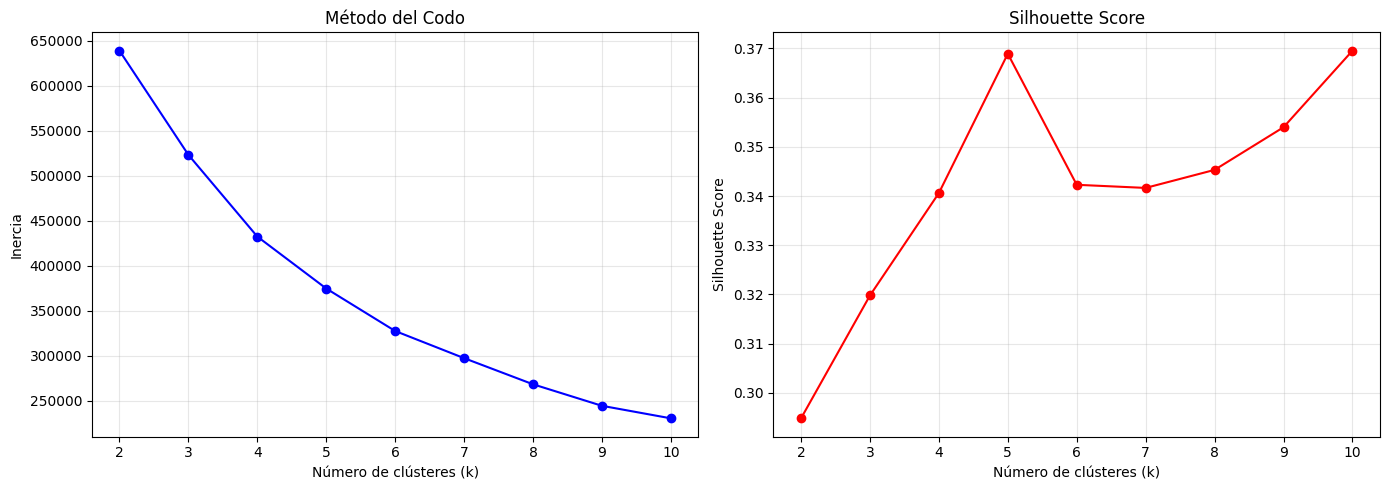


Usando k = 6 clústeres


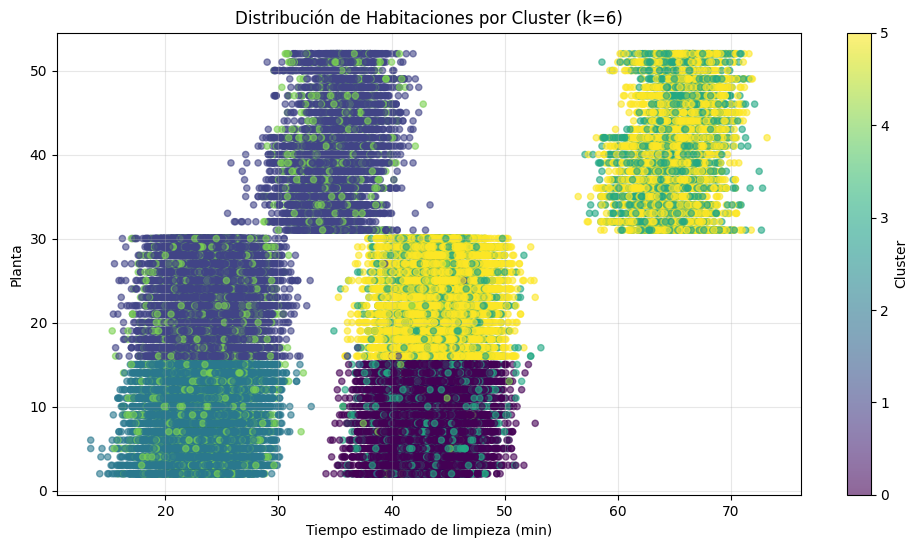


Estadísticas por cluster:
        planta         tiempo_estimado             late_checkout is_checkout  \
          mean min max            mean   min   max          mean        mean   
cluster                                                                        
0         8.52   2  15           43.15  34.2  52.7           0.0        1.00   
1        27.60  16  52           26.94  15.4  46.4           0.0        0.00   
2         8.48   2  15           23.20  13.4  42.5           0.0        0.00   
3        20.39   2  52           48.58  34.9  72.8           1.0        1.00   
4        17.54   2  52           26.13  15.3  50.4           0.0        0.06   
5        26.78  16  52           48.53  35.3  73.2           0.0        1.00   

        noches_estancia num_huespedes tiene_ninos  
                   mean          mean        mean  
cluster                                            
0                  1.73          1.75        0.00  
1                  4.24          1.86       

In [ ]:
# =============================================================================
# ENTRENAMIENTO DE K-MEANS PARA SEGMENTACIÓN DE HABITACIONES
# =============================================================================

import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df_train = pd.read_csv('/content/drive/MyDrive/PERSONAL PROJECTS/Hotel_Checkout/hotel_train_2024.csv')

# =============================================================================
# MODIFICADO: Usar datos por habitación en lugar de agregados por planta
# =============================================================================
# Seleccionar características a nivel de habitación
df_habitaciones_features = df_train[['habitacion_id', 'planta', 'tiempo_estimado',
                                      'late_checkout', 'is_checkout', 'noches_estancia',
                                      'num_huespedes', 'tiene_ninos', 'sector']].copy()

# Codificar sector como número
sector_mapping = {'bajo': 0, 'medio': 1, 'alto': 2}
df_habitaciones_features['sector_num'] = df_habitaciones_features['sector'].map(sector_mapping)

# Características para el clustering (cada fila es una habitación)
features_kmeans = ['planta', 'tiempo_estimado', 'late_checkout', 'is_checkout',
                   'noches_estancia', 'num_huespedes', 'tiene_ninos', 'sector_num']

X = df_habitaciones_features[features_kmeans].values
# =============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =============================================================================
# MODIFICADO: Evaluar número óptimo de clusters con una muestra (por eficiencia)
# =============================================================================
# Para evitar calcular silhouette_score en todo el dataset (puede ser lento)
sample_size = min(10000, len(X_scaled))
X_sample = X_scaled[np.random.choice(len(X_scaled), sample_size, replace=False)]

inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    # Calcular silhouette score solo en la muestra
    labels_sample = kmeans.predict(X_sample)
    silhouette_scores.append(silhouette_score(X_sample, labels_sample))
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertia, 'bo-')
axes[0].set_xlabel('Número de clústeres (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Número de clústeres (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_optimo = 6
print(f"\nUsando k = {k_optimo} clústeres")

# =============================================================================
# MODIFICADO: Entrenar modelo final con todos los datos
# =============================================================================
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_habitaciones_features['cluster'] = kmeans_final.fit_predict(X_scaled)

# Visualizar distribución de clusters por tiempo estimado
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_habitaciones_features['tiempo_estimado'],
                      df_habitaciones_features['planta'],
                      c=df_habitaciones_features['cluster'], cmap='viridis',
                      s=20, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Tiempo estimado de limpieza (min)')
plt.ylabel('Planta')
plt.title(f'Distribución de Habitaciones por Cluster (k={k_optimo})')
plt.grid(True, alpha=0.3)
plt.show()

print("\nEstadísticas por cluster:")
cluster_stats = df_habitaciones_features.groupby('cluster').agg({
    'planta': ['mean', 'min', 'max'],
    'tiempo_estimado': ['mean', 'min', 'max'],
    'late_checkout': 'mean',
    'is_checkout': 'mean',
    'noches_estancia': 'mean',
    'num_huespedes': 'mean',
    'tiene_ninos': 'mean'
}).round(2)
print(cluster_stats)

print("\nDescripción de perfiles por cluster:")
for cluster in sorted(df_habitaciones_features['cluster'].unique()):
    df_cluster = df_habitaciones_features[df_habitaciones_features['cluster'] == cluster]
    tiempo_medio = df_cluster['tiempo_estimado'].mean()
    pct_checkout = df_cluster['is_checkout'].mean() * 100
    pct_late = df_cluster['late_checkout'].mean() * 100
    pct_ninos = df_cluster['tiene_ninos'].mean() * 100

    # Determinar perfil basado en características
    if tiempo_medio > 35:
        perfil = "🔬 Limpieza muy profunda"
    elif tiempo_medio > 28:
        perfil = "📊 Limpieza media"
    else:
        perfil = "⚡ Limpieza rápida"

    if pct_checkout > 60:
        perfil += " (mayoría check-outs)"
    elif pct_checkout < 30:
        perfil += " (mayoría stay-overs)"

    print(f"\nCluster {cluster}: {perfil}")
    print(f"  Tiempo medio: {tiempo_medio:.1f} min")
    print(f"  Check-outs: {pct_checkout:.1f}%")
    print(f"  Late checkouts: {pct_late:.1f}%")
    print(f"  Con niños: {pct_ninos:.1f}%")
    print(f"  Plantas: {df_cluster['planta'].min():.0f}-{df_cluster['planta'].max():.0f}")
# =============================================================================

# =============================================================================
# MODIFICADO: Guardar mapeo de clusters por habitación para uso en app.py
# =============================================================================
cluster_dict = dict(zip(df_habitaciones_features['habitacion_id'],
                        df_habitaciones_features['cluster']))

kmeans_artifacts = {
    'modelo': kmeans_final,
    'scaler': scaler,
    'features': features_kmeans,
    'k_optimo': k_optimo,
    'cluster_dict': cluster_dict,  # Mapeo rápido habitación -> cluster
    'cluster_stats': cluster_stats.to_dict(),
    'df_cluster_stats': df_habitaciones_features.groupby('cluster').agg({
        'tiempo_estimado': 'mean',
        'is_checkout': 'mean',
        'late_checkout': 'mean',
        'tiene_ninos': 'mean'
    }).round(2).to_dict()
}
# =============================================================================

with open('kmeans.pkl', 'wb') as f:
    pickle.dump(kmeans_artifacts, f)

print("\n✅ Modelo guardado: kmeans.pkl")

# MODELO NLP (MULTINOMIAL)

Train con opiniones: 32455
Test con opiniones: 32482

Distribución de sentimientos en train:
sentimiento_nlp
neutral     14564
positivo     9043
negativo     8848
Name: count, dtype: int64

Accuracy Train: 0.8018 (80.18%)
Accuracy Test:  0.8005 (80.05%)

Classification Report (Test):
              precision    recall  f1-score   support

    negativo       0.80      0.72      0.76      8824
     neutral       0.80      0.89      0.84     14646
    positivo       0.80      0.74      0.77      9012

    accuracy                           0.80     32482
   macro avg       0.80      0.78      0.79     32482
weighted avg       0.80      0.80      0.80     32482



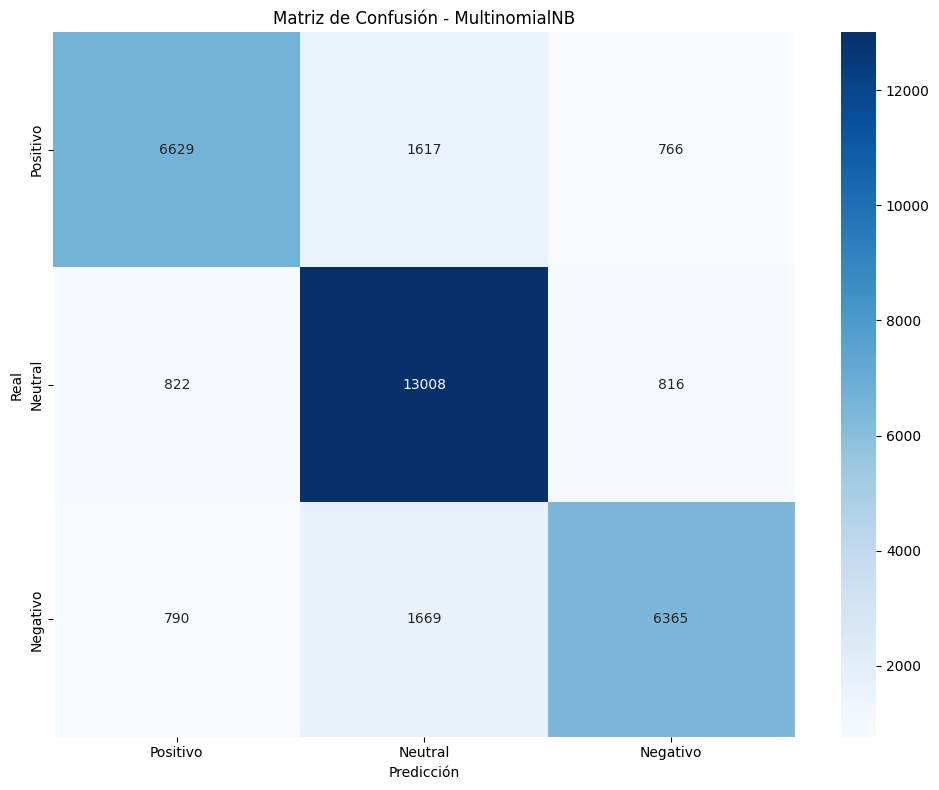

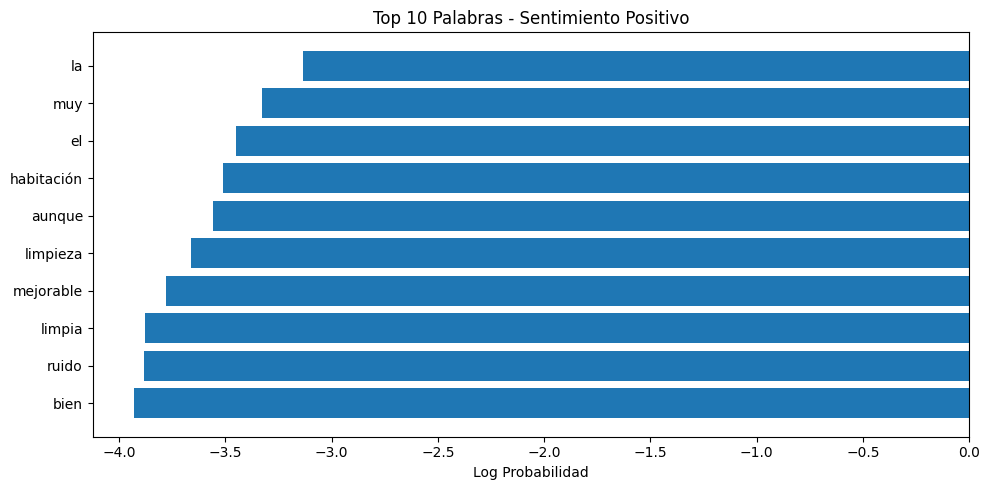


Top palabras positivas: ['bien', 'ruido', 'limpia', 'mejorable', 'limpieza', 'aunque', 'habitación', 'el', 'muy', 'la']

✅ Modelo guardado: nlp.pkl


In [ ]:
# =======================================
# ENTRENAMIENTO NLP CON MULTINOMIAL NB
# =======================================

import pandas as pd
import numpy as np
import pickle
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

df_train = pd.read_csv('/content/drive/MyDrive/PERSONAL PROJECTS/Hotel_Checkout/hotel_train_2024.csv')
df_test = pd.read_csv('/content/drive/MyDrive/PERSONAL PROJECTS/Hotel_Checkout/hotel_test_2025.csv')

df_train = df_train[df_train['opinion_cliente'].notna() & (df_train['opinion_cliente'] != '')].copy()
df_test = df_test[df_test['opinion_cliente'].notna() & (df_test['opinion_cliente'] != '')].copy()

print(f"Train con opiniones: {len(df_train)}")
print(f"Test con opiniones: {len(df_test)}")

print("\nDistribución de sentimientos en train:")
print(df_train['sentimiento_nlp'].value_counts())

def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    texto = re.sub(r'\d+', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df_train['texto_limpio'] = df_train['opinion_cliente'].apply(limpiar_texto)
df_test['texto_limpio'] = df_test['opinion_cliente'].apply(limpiar_texto)

X_train = df_train['texto_limpio'].values
y_train = df_train['sentimiento_nlp'].values
X_test = df_test['texto_limpio'].values
y_test = df_test['sentimiento_nlp'].values

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 1),
        min_df=3,
        max_df=0.8
    )),
    ('clf', MultinomialNB(alpha=0.5))
])

pipeline.fit(X_train, y_train)

y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"\nAccuracy Train: {acc_train:.4f} ({acc_train:.2%})")
print(f"Accuracy Test:  {acc_test:.4f} ({acc_test:.2%})")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test))

# Crear figura con tamaño adecuado
plt.figure(figsize=(10, 8))

cm = confusion_matrix(y_test, y_pred_test, labels=['positivo', 'neutral', 'negativo'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positivo', 'Neutral', 'Negativo'],
            yticklabels=['Positivo', 'Neutral', 'Negativo'])
plt.title('Matriz de Confusión - MultinomialNB')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

# Segunda gráfica (opcional)
plt.figure(figsize=(10, 5))
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
log_probs = pipeline.named_steps['clf'].feature_log_prob_

clases = list(pipeline.named_steps['clf'].classes_)
if 'positivo' in clases:
    pos_idx = clases.index('positivo')
    top_pos = np.argsort(log_probs[pos_idx])[-10:]
    palabras_pos = [feature_names[i] for i in top_pos]
    valores_pos = log_probs[pos_idx][top_pos]

    plt.barh(range(10), valores_pos)
    plt.yticks(range(10), palabras_pos)
    plt.xlabel('Log Probabilidad')
    plt.title('Top 10 Palabras - Sentimiento Positivo')
    plt.tight_layout()
    plt.show()

    print("\nTop palabras positivas:", palabras_pos)

with open('nlp.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

print("\n✅ Modelo guardado: nlp.pkl")

In [ ]:
# =============================================================================
# PRUEBA DEL MODELO CON FRASES PERSONALIZADAS DEL NPL PREENTRENADO
# =============================================================================

# Cargar el modelo guardado (si no está ya en memoria)
# with open('nlp.pkl', 'rb') as f:
#     pipeline = pickle.load(f)

def predecir_sentimiento(texto, modelo=pipeline):
    """
    Función para predecir el sentimiento de un texto
    """
    # Limpiar el texto
    texto_limpio = limpiar_texto(texto)

    # Hacer predicción
    prediccion = modelo.predict([texto_limpio])[0]

    # Obtener probabilidades
    probabilidades = modelo.predict_proba([texto_limpio])[0]
    clases = modelo.classes_

    # Mostrar resultados
    print(f"\n📝 Texto analizado: '{texto}'")
    print(f"🔍 Texto limpio: '{texto_limpio}'")
    print(f"\n🎯 Predicción: {prediccion.upper()}")
    print("\n📊 Probabilidades:")

    for clase, prob in zip(clases, probabilidades):
        print(f"   {clase}: {prob:.2%}")

    return prediccion, dict(zip(clases, probabilidades))

# ============================================
# PRUEBA CON DIFERENTES FRASES
# ============================================

frase_personalizada = "En este hotel se cuidan muy poco los detalles, nos hemos sentido ninguneados"
predecir_sentimiento(frase_personalizada)


📝 Texto analizado: 'En este hotel se cuidan muy pocos los detalles, nos hemos sentido ninguneados'
🔍 Texto limpio: 'en este hotel se cuidan muy pocos los detalles nos hemos sentido ninguneados'

🎯 Predicción: POSITIVO

📊 Probabilidades:
   negativo: 29.87%
   neutral: 13.97%
   positivo: 56.16%


(np.str_('positivo'),
 {np.str_('negativo'): np.float64(0.2987366158635186),
  np.str_('neutral'): np.float64(0.1396553695028963),
  np.str_('positivo'): np.float64(0.5616080146335857)})

#MODELO PREENTRENADO HuggingFace para NLP

In [ ]:
# ====================
# NPL CON TRANSFORMER
# ====================

from transformers import pipeline

# Cargamos un modelo específico para español
classifier = pipeline("sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis")

resultado = classifier("En este hotel se cuidan muy poco los detalles, nos hemos sentido ninguneados")
print(resultado)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': 'NEG', 'score': 0.9650237560272217}]
